In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lameg.util import load_meg_sensor_data

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
vc_preproc_data_dir='/home/common/bonaiuto/cued_action_meg/derivatives/processed'
sp_preproc_data_dir='/home/common/bonaiuto/auditory_laminar/derivatives/processed/'
visual_preproc_data_dir='/home/bonaiuto/visual_laminar/V1_ERF_meeg_spm/'

In [4]:
cued_subjects=[
    'sub-001',
    'sub-002',
    'sub-003',
    'sub-004',
    'sub-005',
    'sub-006',
    'sub-007',
    'sub-008'
]
cued_subject_sex={
    'sub-001': 'm',
    'sub-002': 'm',
    'sub-003': 'm',
    'sub-004': 'm',
    'sub-005': 'f',
    'sub-006': 'm',
    'sub-007': 'f',
    'sub-008': 'm'
}
cued_sessions={
    'sub-001': ['ses-01'],
    'sub-002': ['ses-03','ses-04','ses-05','ses-06'],
    'sub-003': ['ses-03'],
    'sub-004': ['ses-01'],
    'sub-005': ['ses-01','ses-03','ses-04'],
    'sub-006': ['ses-03'],
    'sub-007': ['ses-01','ses-02','ses-03','ses-04'],
    'sub-008': ['ses-03','ses-04','ses-05']
}
        
mf_win=[-75, -25]
mefI_win=[15, 55]

cued_mf_peak_snrs=[]
cued_mefI_peak_snrs=[]
cued_n_trials=[]

for subject in cued_subjects:
    subj_sensor_data=[]    
    for sess_idx, session in enumerate(cued_sessions[subject]):
        data_dir=os.path.join(vc_preproc_data_dir,subject,session,'spm')
        orig_data_file=f'spm_converted_{subject}-{session}-motor-epo.mat'
        sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(data_dir, orig_data_file))
        subj_sensor_data.append(sensor_data)
    subj_sensor_data=np.concatenate(subj_sensor_data, axis=-1)
            
    n_trials = subj_sensor_data.shape[-1]
    cued_n_trials.append(n_trials)

    # Compute mean signal across trials (shape: n_channels x n_times)
    mean_signal = np.mean(subj_sensor_data, axis=2)
    # Compute residual noise (trial-by-trial deviations from mean)
    noise = subj_sensor_data - mean_signal[:, :, np.newaxis]
    # Compute RMS of signal and noise over channels
    rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
    rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
    # Compute SNR time series in dB
    snr_db = 20 * np.log10(rms_signal / rms_noise)

    mf_idx=(sensor_time>=mf_win[0]) & (sensor_time<=mf_win[1])
    mf_snr=np.mean(snr_db[mf_idx])
    cued_mf_peak_snrs.append(mf_snr)

    mefI_idx=(sensor_time>=mefI_win[0]) & (sensor_time<=mefI_win[1])
    mefI_snr=np.mean(snr_db[mefI_idx])
    cued_mefI_peak_snrs.append(mefI_snr)

    print(f'{subject} n_trials={n_trials}, MF SNR={mf_snr:0.2f} dB, MEFI SNR={mefI_snr:0.2f} dB')
            

sub-001 n_trials=266, MF SNR=-6.35 dB, MEFI SNR=-3.15 dB
sub-002 n_trials=1073, MF SNR=-6.43 dB, MEFI SNR=-8.28 dB
sub-003 n_trials=269, MF SNR=-11.24 dB, MEFI SNR=-5.00 dB
sub-004 n_trials=268, MF SNR=-11.26 dB, MEFI SNR=-4.51 dB
sub-005 n_trials=805, MF SNR=-10.98 dB, MEFI SNR=-6.23 dB
sub-006 n_trials=269, MF SNR=-10.97 dB, MEFI SNR=-5.40 dB
sub-007 n_trials=1074, MF SNR=-5.53 dB, MEFI SNR=-3.47 dB
sub-008 n_trials=794, MF SNR=-10.35 dB, MEFI SNR=-3.40 dB


In [5]:
self_subjects = [
    'sub-104',
    'sub-105',
    'sub-114'
]
self_subject_sex = {
    'sub-104': 'f',
    'sub-105': 'f',
    'sub-114': 'f'
}

self_sessions = {
    'sub-104': ['ses-01'],
    'sub-105': ['ses-01'],
    'sub-114': ['ses-01']
}

epo_type='btn_trial'
        
mf_win=[-75, -25]
mefI_win=[15, 55]

self_mf_peak_snrs=[]
self_mefI_peak_snrs=[]
self_n_trials=[]

for subject in self_subjects:
    for sess_idx, session in enumerate(self_sessions[subject]):
        data_dir=os.path.join(sp_preproc_data_dir,subject,session,'spm')
        orig_data_file = f'spm_autoreject-{subject}-{session}-{epo_type}-epo.mat'
        sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(data_dir, orig_data_file))
        
        n_trials = sensor_data.shape[-1]
        self_n_trials.append(n_trials)
    
        # Compute mean signal across trials (shape: n_channels x n_times)
        mean_signal = np.mean(sensor_data, axis=2)
        # Compute residual noise (trial-by-trial deviations from mean)
        noise = sensor_data - mean_signal[:, :, np.newaxis]
        # Compute RMS of signal and noise over channels
        rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
        rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
        # Compute SNR time series in dB
        snr_db = 20 * np.log10(rms_signal / rms_noise)

        mf_idx=(sensor_time>=mf_win[0]) & (sensor_time<=mf_win[1])
        mf_snr=np.max(snr_db[mf_idx])
        self_mf_peak_snrs.append(mf_snr)

        mefI_idx=(sensor_time>=mefI_win[0]) & (sensor_time<=mefI_win[1])
        mefI_snr=np.max(snr_db[mefI_idx])
        self_mefI_peak_snrs.append(mefI_snr)

        print(f'{subject} {session} n_trials={n_trials}, MF SNR={mf_snr:0.2f} dB, MEFI SNR={mefI_snr:0.2f} dB')

sub-104 ses-01 n_trials=325, MF SNR=-12.20 dB, MEFI SNR=-10.13 dB
sub-105 ses-01 n_trials=322, MF SNR=-10.53 dB, MEFI SNR=-5.15 dB
sub-114 ses-01 n_trials=316, MF SNR=-12.32 dB, MEFI SNR=-4.17 dB


In [6]:
visual_sex_df=pd.read_csv('/home/bonaiuto/visual_laminar/sex_v1_all.csv')
visual_left_n_trials=[]
visual_left_peak_snrs=[]
visual_right_n_trials=[]
visual_right_peak_snrs=[]

vis_win=[50,150]

left_stim_files=sorted(glob.glob(os.path.join(visual_preproc_data_dir,'*_left_stim_*.mat')))
right_stim_files=sorted(glob.glob(os.path.join(visual_preproc_data_dir,'*_right_stim_*.mat')))
for left_stim_file in left_stim_files:
    sensor_data, sensor_time, ch_names = load_meg_sensor_data(left_stim_file)
        
    n_trials = sensor_data.shape[-1]
    visual_left_n_trials.append(n_trials)

    # Compute mean signal across trials (shape: n_channels x n_times)
    mean_signal = np.mean(sensor_data, axis=2)
    # Compute residual noise (trial-by-trial deviations from mean)
    noise = sensor_data - mean_signal[:, :, np.newaxis]
    # Compute RMS of signal and noise over channels
    rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
    rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
    # Compute SNR time series in dB
    snr_db = 20 * np.log10(rms_signal / rms_noise)

    v_idx=(sensor_time>=vis_win[0]) & (sensor_time<=vis_win[1])
    v_snr=np.mean(snr_db[v_idx])
    visual_left_peak_snrs.append(v_snr)

    if v_snr<-15:
        print(f'{left_stim_file}, n_trials={n_trials}, SNR={v_snr:0.2f} dB')    

for right_stim_file in right_stim_files:
    sensor_data, sensor_time, ch_names = load_meg_sensor_data(right_stim_file)
        
    n_trials = sensor_data.shape[-1]
    visual_right_n_trials.append(n_trials)

    # Compute mean signal across trials (shape: n_channels x n_times)
    mean_signal = np.mean(sensor_data, axis=2)
    # Compute residual noise (trial-by-trial deviations from mean)
    noise = sensor_data - mean_signal[:, :, np.newaxis]
    # Compute RMS of signal and noise over channels
    rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
    rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
    # Compute SNR time series in dB
    snr_db = 20 * np.log10(rms_signal / rms_noise)

    v_idx=(sensor_time>=vis_win[0]) & (sensor_time<=vis_win[1])
    v_snr=np.mean(snr_db[v_idx])
    visual_right_peak_snrs.append(v_snr)

    if v_snr<-15:
        print(f'{right_stim_file}, n_trials={n_trials}, SNR={v_snr:0.2f} dB')    

/home/bonaiuto/visual_laminar/V1_ERF_meeg_spm/spm_sub-115_ses-01_task-V100V100_meg_no_mxf_left_stim_nrg_ERF_epo.mat, n_trials=80, SNR=-16.11 dB
/home/bonaiuto/visual_laminar/V1_ERF_meeg_spm/spm_sub-132_ses-01_task-V100V100_meg_no_mxf_right_stim_nrg_ERF_epo.mat, n_trials=105, SNR=-18.96 dB
/home/bonaiuto/visual_laminar/V1_ERF_meeg_spm/spm_sub-133_ses-01_task-V100V100_meg_no_mxf_right_stim_nrg_ERF_epo.mat, n_trials=96, SNR=-18.40 dB
/home/bonaiuto/visual_laminar/V1_ERF_meeg_spm/spm_sub-137_ses-01_task-V100V100_meg_no_mxf_right_stim_nrg_ERF_epo.mat, n_trials=102, SNR=-17.89 dB
/home/bonaiuto/visual_laminar/V1_ERF_meeg_spm/spm_sub-141_ses-01_task-V100V100_meg_no_mxf_right_stim_nrg_ERF_epo.mat, n_trials=118, SNR=-23.03 dB
/home/bonaiuto/visual_laminar/V1_ERF_meeg_spm/spm_sub-142_ses-01_task-V100V100_meg_no_mxf_right_stim_nrg_ERF_epo.mat, n_trials=104, SNR=-18.91 dB


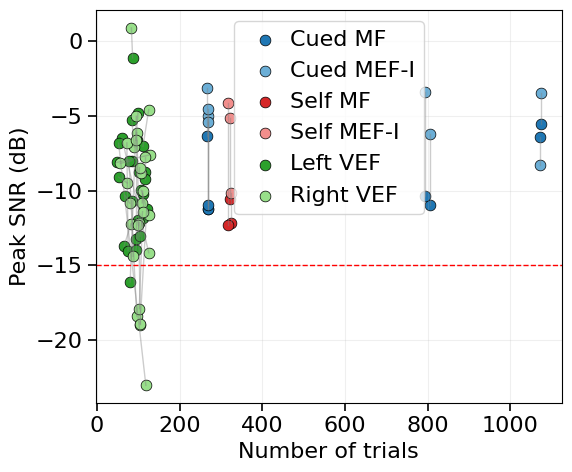

In [7]:
plt.figure(figsize=(6, 5))

colors = {
    "cued_mf":    "#1f77b4",  # dark blue
    "cued_mefi":  "#6baed6",  # light blue
    "self_mf":    "#d62728",  # dark red
    "self_mefi":  "#f28e8c",   # light red
    "left_vis":  "#2ca02c",  # dark green
    "right_vis": "#98df8a"   # light green
}

# Scatter plots
plt.scatter(cued_n_trials, cued_mf_peak_snrs,
            s=60, edgecolor='k', linewidth=0.5,
            color=colors["cued_mf"],
            label='Cued MF')

plt.scatter(cued_n_trials, cued_mefI_peak_snrs,
            s=60, edgecolor='k', linewidth=0.5,
            color=colors["cued_mefi"],
            label='Cued MEF-I')

plt.scatter(self_n_trials, self_mf_peak_snrs,
            s=60, edgecolor='k', linewidth=0.5,
            color=colors["self_mf"],
            label='Self MF')

plt.scatter(self_n_trials, self_mefI_peak_snrs,
            s=60, edgecolor='k', linewidth=0.5,
            color=colors["self_mefi"],
            label='Self MEF-I')

plt.scatter(visual_left_n_trials, visual_left_peak_snrs,
            s=60, edgecolor='k', linewidth=0.5,
            color=colors["left_vis"],
            label='Left VEF')

plt.scatter(visual_right_n_trials, visual_right_peak_snrs,
            s=60, edgecolor='k', linewidth=0.5,
            color=colors["right_vis"],
            label='Right VEF')

for i in range(len(cued_n_trials)):
    plt.plot([cued_n_trials[i], cued_n_trials[i]],
             [cued_mf_peak_snrs[i], cued_mefI_peak_snrs[i]],
             color='gray', alpha=0.4, linewidth=1)

for i in range(len(self_n_trials)):
    plt.plot([self_n_trials[i], self_n_trials[i]],
             [self_mf_peak_snrs[i], self_mefI_peak_snrs[i]],
             color='gray', alpha=0.4, linewidth=1)
    
for i in range(len(visual_left_n_trials)):
    plt.plot([visual_left_n_trials[i], visual_right_n_trials[i]],
             [visual_left_peak_snrs[i], visual_right_peak_snrs[i]],
             color='gray', alpha=0.4, linewidth=1)


# Labels and formatting
plt.xlabel('Number of trials')
plt.ylabel('Peak SNR (dB)')
plt.axhline(-15, color='r', linestyle='--', linewidth=1)  # your exclusion threshold
plt.legend(frameon=True)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figure_S14_snr_vs_trials.pdf', dpi=300)

In [8]:
data={
    'condition': [],
    'subject': [],
    'sex': [],
    'n_trials': [],
    'snr': []
}
for i in range(len(cued_n_trials)):
    data['condition'].append('cued_mf')
    data['subject'].append(cued_subjects[i])
    data['sex'].append(cued_subject_sex[cued_subjects[i]])
    data['n_trials'].append(cued_n_trials[i])
    data['snr'].append(cued_mf_peak_snrs[i])

for i in range(len(cued_n_trials)):
    data['condition'].append('cued_mefi')
    data['subject'].append(cued_subjects[i])
    data['sex'].append(cued_subject_sex[cued_subjects[i]])
    data['n_trials'].append(cued_n_trials[i])
    data['snr'].append(cued_mefI_peak_snrs[i])

for i in range(len(self_n_trials)):
    data['condition'].append('self_mf')
    data['subject'].append(self_subjects[i])
    data['sex'].append(self_subject_sex[self_subjects[i]])
    data['n_trials'].append(self_n_trials[i])
    data['snr'].append(self_mf_peak_snrs[i])

for i in range(len(self_n_trials)):
    data['condition'].append('self_mefi')
    data['subject'].append(self_subjects[i])
    data['sex'].append(self_subject_sex[self_subjects[i]])
    data['n_trials'].append(self_n_trials[i])
    data['snr'].append(self_mefI_peak_snrs[i])

for i in range(len(visual_left_n_trials)):
    data['condition'].append('visual_left')
    data['subject'].append(visual_sex_df['subjectID'][i])
    data['sex'].append(visual_sex_df['sex'][i])
    data['n_trials'].append(visual_left_n_trials[i])
    data['snr'].append(visual_left_peak_snrs[i])

for i in range(len(visual_right_n_trials)):
    data['condition'].append('visual_right')
    data['subject'].append(visual_sex_df['subjectID'][i])
    data['sex'].append(visual_sex_df['sex'][i])
    data['n_trials'].append(visual_right_n_trials[i])
    data['snr'].append(visual_right_peak_snrs[i])
    
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_S14.csv', index=False)